In [1]:
import pickle
from pathlib import Path

DATASET_PATH = r"C:\Users\HP\Desktop\RF Signal Processing\RF-Signal-Classification-using-ML\data\raw\RML2016.10a_dict.pkl"

with open(DATASET_PATH, "rb") as file:
    dataset = pickle.load(file, encoding="latin1")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [2]:
mods = sorted(set(k[0] for k in dataset.keys()))
print("Modulations:")
print(mods)

Modulations:
['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']


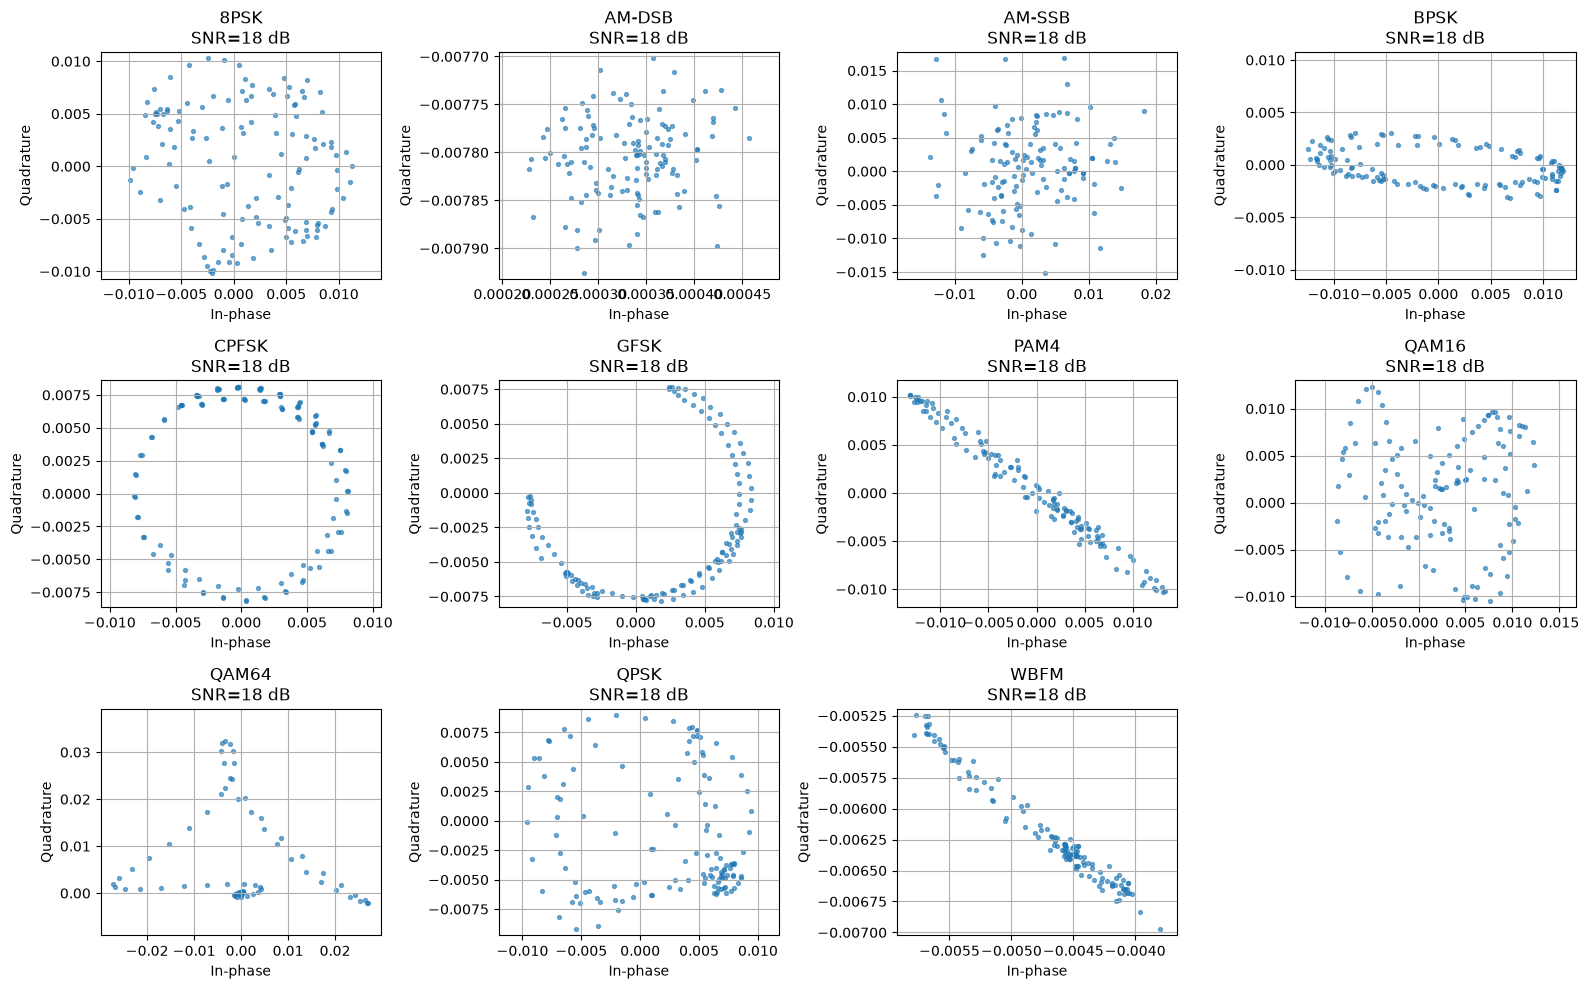

In [3]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(16, 10))

for i, mod in enumerate(mods):
    
    # Find highest SNR for this modulation
    snrs = [k[1] for k in dataset.keys() if k[0] == mod]
    best_snr = max(snrs)

    samples = dataset[(mod, best_snr)]

    # Random sample
    signal = samples[np.random.randint(len(samples))]

    # I and Q
    I = signal[0]
    Q = signal[1]

    plt.subplot(3, 4, i + 1)
    plt.scatter(I, Q, s=8, alpha=0.6)
    plt.title(f"{mod}\nSNR={best_snr} dB")
    plt.xlabel("In-phase")
    plt.ylabel("Quadrature")
    plt.grid(True)
    plt.axis("equal")

plt.tight_layout()
plt.show()